# 🛒 IronKaggle: Sales Prediction Analysis

## 📁 Project Overview
This notebook contains a comprehensive analysis and machine learning pipeline for predicting store sales. The goal is to identify key factors influencing sales and build a reliable predictive model.


### 🗺️ Table of Contents
1. [Environment Setup](#environment-setup)
2. [Data Acquisition](#data-acquisition)
3. [Data Preprocessing & Cleaning](#data-preprocessing-&-cleaning)
4. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-(eda))
5. [Feature Engineering & Selection](#feature-engineering-&-selection)
6. [Model Building & Training](#model-building-&-training)
7. [Model Evaluation](#model-evaluation)
8. [Conclusions & Insights](#conclusions-&-insights)

## 🛠️ 1. Environment Setup
Configuring the environment and importing essential libraries.

In [2]:
# Standard Library Imports
import pandas as pd
import numpy as np
import warnings

# Machine Learning Imports
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialization
le = LabelEncoder()


## 🧹 3. Data Preprocessing & Cleaning
Refining the dataset for analysis and modeling.

In [4]:
def perform_data_cleanup(df):
    """
    Performs comprehensive data cleaning and preparation.
    - Creates a copy to avoid SettingWithCopyWarning
    - Parsons 'date' and sorts chronologically
    - Filters for only open store records
    - Encodes 'state_holiday' categorical variable
    """
    df_clean = df.copy()
    
    # Convert 'date' to datetime objects and sort chronologically
    df_clean['date'] = pd.to_datetime(df_clean['date'], format='%Y-%m-%d')
    df_clean = df_clean.sort_values(['date'])
    
    # Filter records to include only days when the store was open
    df_clean = df_clean[df_clean['open'] == 1]
    
    # Encode categorical 'state_holiday' labels into numerical values
    df_clean['state_holiday'] = le.fit_transform(df_clean['state_holiday'])
    
    return df_clean


In [5]:
# Apply the unified cleaning function
df_filtered = perform_data_cleanup(df)

# Initial verification of the cleaned dataset
display(df_filtered.head())
print(f"Dataset shape after filtering: {df_filtered.shape}")


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
392388,338008,335,2,2013-01-01,482,1,0,1,1,2401
482306,13557,948,2,2013-01-01,1039,1,0,1,1,4491
222078,253110,423,2,2013-01-01,1751,1,0,1,1,9643
545183,512628,530,2,2013-01-01,532,1,0,1,1,2907
147155,277247,274,2,2013-01-01,729,1,0,1,1,3102


Dataset shape after filtering: (532016, 10)


## 📈 4. Exploratory Data Analysis (EDA)
Analyzing distributions, statistics, and outliers in the data.

In [8]:
# Generate summary statistics for numerical columns in the cleaned dataset
df_filtered.describe()


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
count,532016.000000,532016.000000,532016.000000,532016,532016.000000,532016.0,532016.000000,532016.000000,532016.000000,532016.000000
mean,355998.345674,558.050115,3.523479,2014-04-11 01:51:15.336079,762.960407,1.0,0.446520,0.001460,0.193229,6959.251679
min,0.000000,1.000000,1.000000,2013-01-01 00:00:00,0.000000,1.0,0.000000,0.000000,0.000000,0.000000
25%,178080.750000,280.000000,2.000000,2013-08-17 00:00:00,519.000000,1.0,0.000000,0.000000,0.000000,4861.000000
50%,355963.500000,558.000000,3.000000,2014-03-31 00:00:00,676.000000,1.0,0.000000,0.000000,0.000000,6372.000000
75%,533943.500000,836.000000,5.000000,2014-12-10 00:00:00,893.000000,1.0,1.000000,0.000000,0.000000,8365.000000
max,712044.000000,1115.000000,7.000000,2015-07-31 00:00:00,5458.000000,1.0,1.000000,3.000000,1.000000,41551.000000
std,205568.449180,321.613167,1.723849,NaN,400.736508,0.0,0.497132,0.048817,0.394832,3105.241710


## 🤖 5. Model Building & Training
Splitting the data and training a predictive model.

In [ ]:
# Define target variable (Sales) and feature matrix
X = df_filtered.drop(columns=['sales', 'store_ID', 'date'])
if 'Unnamed: 0' in X.columns:
    X = X.drop(columns=['Unnamed: 0'])
y = df_filtered['sales']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.20)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


In [ ]:
X_train.info()


In [ ]:
# Identify column types to ensure all selected features are numeric for linear modeling
non_numeric_cols = X_train.select_dtypes(exclude=['number', 'bool']).columns
print("\nNon-numeric columns in training set:", list(non_numeric_cols))


In [48]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generate predictions for both sets to assess fitting
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Calculate performance metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

print(f"Test RMSE: {rmse_test:.2f}")
print(f"Test R2 Score: {r2_test:.4f}")


Test RMSE: 1620.42
Test R2 Score: 0.7307


In [ ]:
print(r2_test)


In [ ]:
#X_trainf= X_train.drop("School_holiday")
#X_trainf


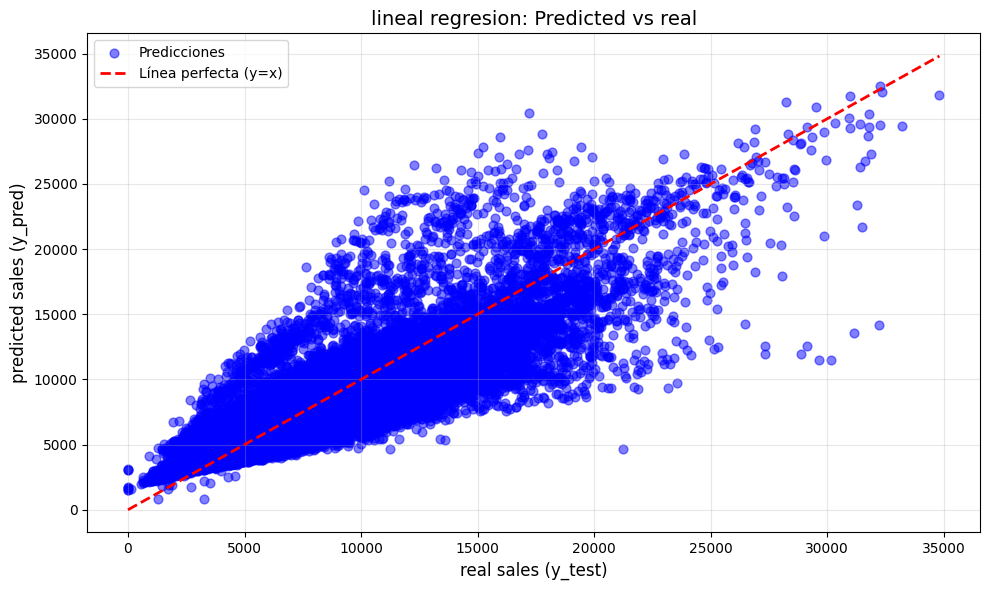

In [49]:
#graph of linnear regresion
import matplotlib.pyplot as plt
import seaborn as sns
# Prediction
y_pred = model.predict(X_test)
# ────────────────────────────────────────────────
# Graph1: predictions vs values
# ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', s=40, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Línea perfecta (y=x)')
plt.xlabel('real sales (y_test)', fontsize=12)
plt.ylabel('predicted sales (y_pred)', fontsize=12)
plt.title('lineal regresion: Predicted vs real', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Get the dates corresponding to the test set
# dates_for_plot = df_filtered.loc[X_test.index, 'date']

# plt.figure(figsize=(14, 7))
# plt.plot(dates_for_plot, y_test, label='Real Sales', color='blue', alpha=0.7)
# plt.plot(dates_for_plot, y_pred, label='Predictions', color='orange', linestyle='--')
# plt.xlabel('Date', fontsize=12)
# plt.ylabel('Sales', fontsize=12)
# plt.title('Real vs Predicted Sales Over Time (Test Set)', fontsize=14)
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


In [ ]:
#second method of analysis, decision trees regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree RMSE:", rmse_dt)
print("Decision Tree R2:", r2_dt)


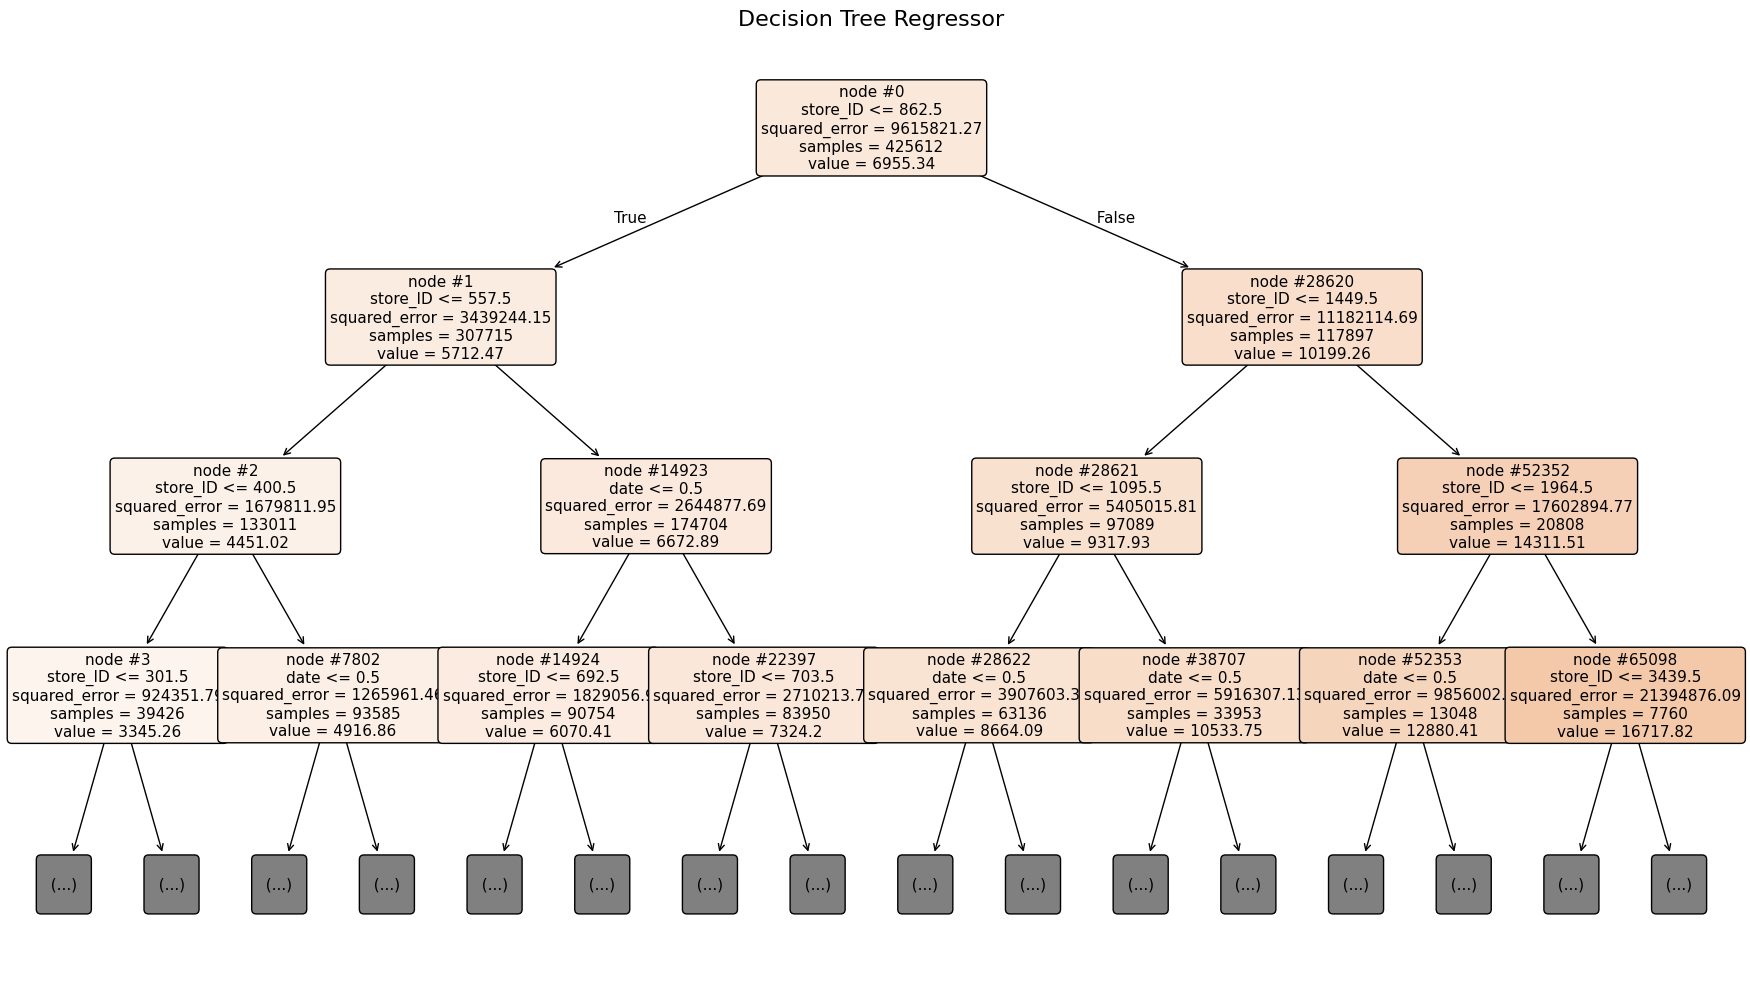

In [50]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))          # make it bigger so text is readable
plot_tree(
    dt_model,
    feature_names= df_filtered.columns,      # ← replace with your real feature names: X.columns.tolist()
    filled=True,                      # colors the nodes
    rounded=True,
    fontsize=11,
    precision=2,                      # decimals in split values
    impurity=True,
    max_depth=3,                     # shows MSE / variance reduction
    node_ids=True                     # optional: shows node numbers
)

plt.title("Decision Tree Regressor", fontsize=16)
plt.tight_layout()
plt.show()


In [51]:
df_filtered.columns


Index(['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday', 'sales'],
      dtype='str')

# Random Forest Regression

In [52]:
# Random forest method and compare results
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=100,       # nmber of estimators
    max_depth=20,         # N
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1               # usa todos los núcleos → más rápido
)

# Fit method
rf.fit(X_train, y_train)
print("Model trained")


Model trained


In [53]:
# Store predictions in a new variable to avoid overwriting y_test
y_pred_rf = rf.predict(X_test)
print("Predictions done")
print(y_pred_rf)


Predictions done
[ 4336.85351048  4598.65633188  6557.25345196 ...  4738.18274597
 13170.0833012   5334.262537  ]


In [54]:
# Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Using y_test (Actual) and y_pred_rf (Predicted)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)
print("Random Forest MAE:", mae_rf)


Random Forest RMSE: 1554.541488136212
Random Forest R2: 0.7521169157466874
Random Forest MAE: 1114.0604269522887


# Random Forest Graphics


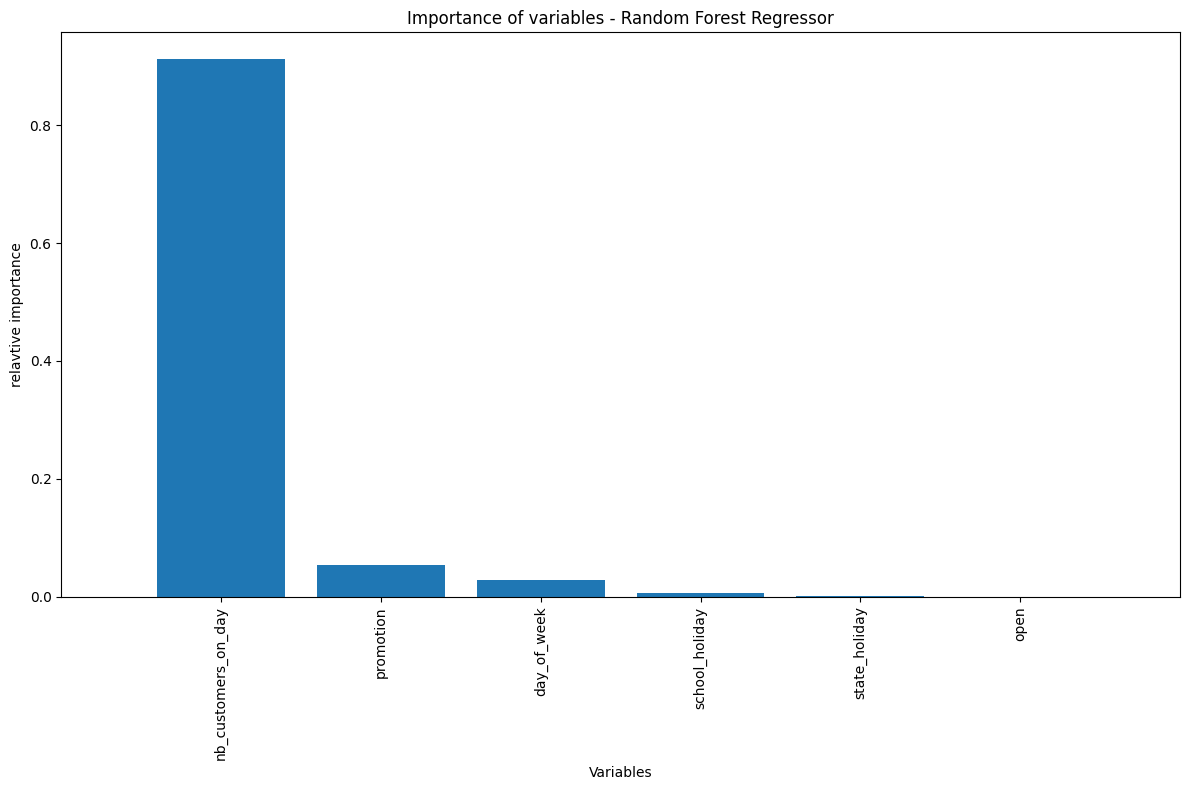

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Importancia de features
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # order desc

plt.figure(figsize=(12, 8))
plt.title("Importance of variables - Random Forest Regressor")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.xlabel("Variables")
plt.ylabel("relavtive importance")
plt.tight_layout()
plt.show()


In [56]:
# Define target variable (Sales) and feature matrix
X = df_filtered.drop(columns=['sales', 'store_ID', 'date'])
if 'Unnamed: 0' in X.columns:
    X = X.drop(columns=['Unnamed: 0'])
y = df_filtered['sales']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0, test_size=0.20)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (425612, 6)
X_test shape: (106404, 6)


In [57]:
rf_2 = RandomForestRegressor(
    n_estimators=100,       # nmber of estimators
    max_depth=3,         # N
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1               # usa todos los núcleos → más rápido
)

# Fit method
rf.fit(X_train, y_train)
print("Model trained")


Model trained


In [58]:
# Store predictions in a new variable to avoid overwriting y_test
y_pred_rf = rf.predict(X_test)
print("Predictions done")
print(y_pred_rf)


Predictions done
[ 4336.85351048  4598.65633188  6557.25345196 ...  4738.18274597
 13170.0833012   5334.262537  ]


In [59]:
# Metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Using y_test (Actual) and y_pred_rf (Predicted)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)
print("Random Forest MAE:", mae_rf)


Random Forest RMSE: 1554.541488136212
Random Forest R2: 0.7521169157466874
Random Forest MAE: 1114.0604269522887


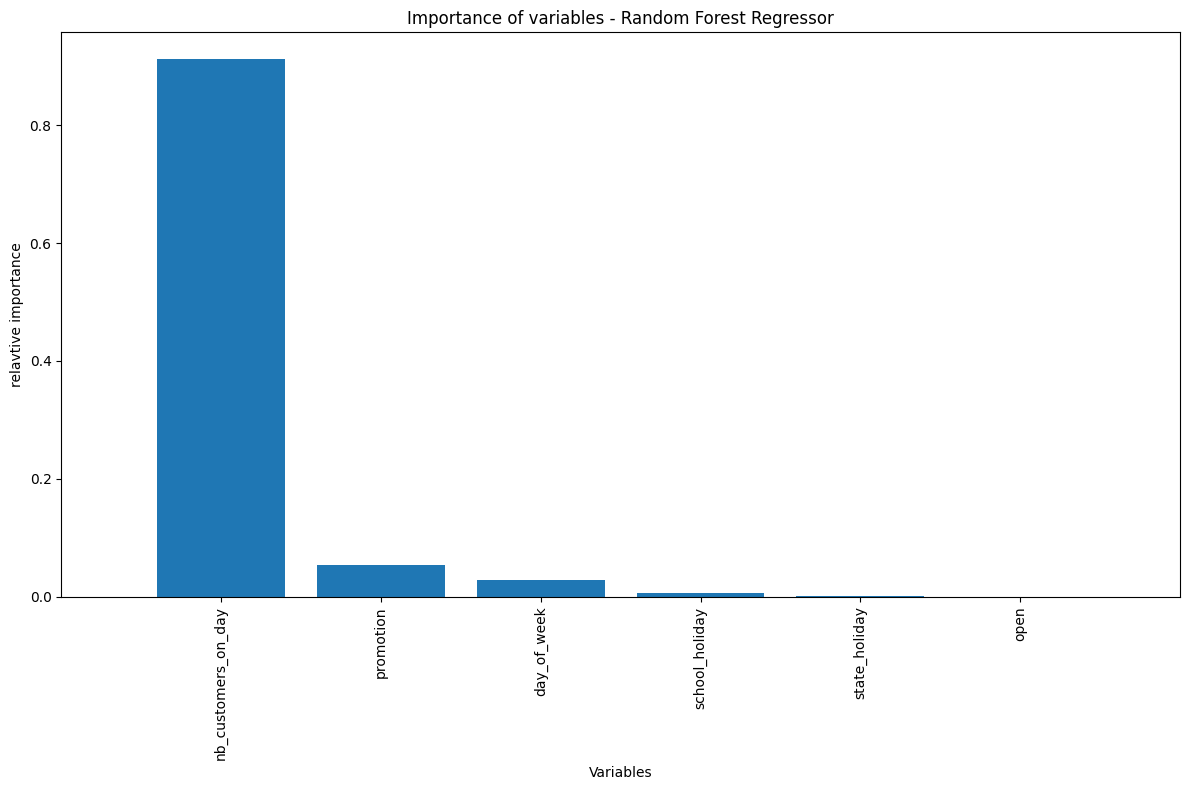

In [60]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Importancia de features
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]  # order desc

plt.figure(figsize=(12, 8))
plt.title("Importance of variables - Random Forest Regressor")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.xlabel("Variables")
plt.ylabel("relavtive importance")
plt.tight_layout()
plt.show()


# Linear Regression Improved

In [61]:
from sklearn.base import np
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
model_2 = LinearRegression()
model.fit(X_train, y_train)
# Make predictios
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)
#Evaluate the model
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
r2_train   = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)
print(f"rmse_test {rmse_test} , r2_test {r2_test}")


rmse_test 1620.4157151125219 , r2_test 0.7306635387617274


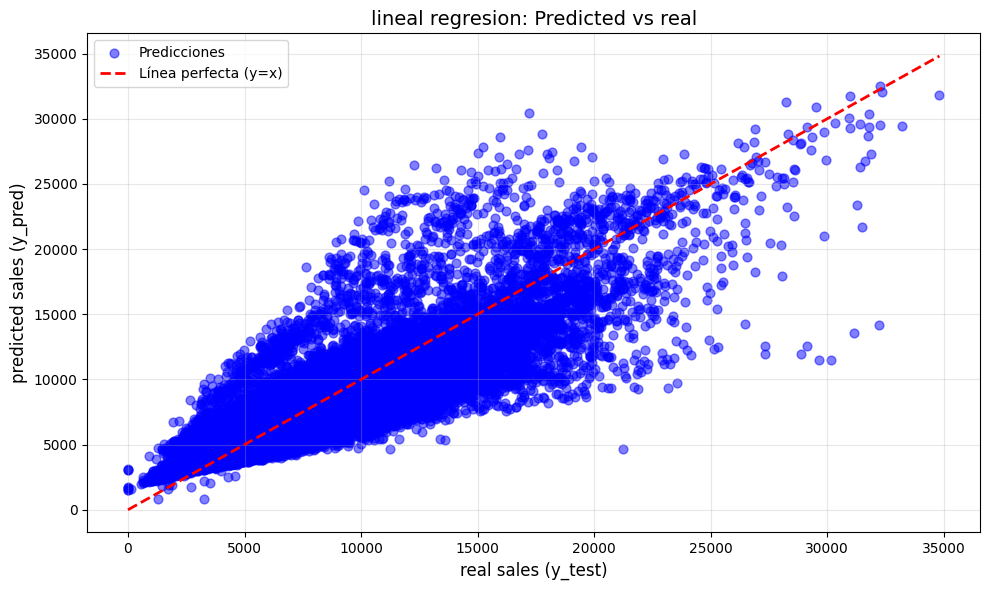

In [62]:
#graph of linnear regresion
import matplotlib.pyplot as plt
import seaborn as sns
# Prediction
y_pred = model.predict(X_test)
# ────────────────────────────────────────────────
# Graph1: predictions vs values
# ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', s=40, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Línea perfecta (y=x)')
plt.xlabel('real sales (y_test)', fontsize=12)
plt.ylabel('predicted sales (y_pred)', fontsize=12)
plt.title('lineal regresion: Predicted vs real', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 🧪 6. Specialized Modeling (Selected Features)
In this section, we train models using only a subset of features ( and ) to observe their individual impact on sales prediction.

In [63]:
# Select specific feature subset
X_2 = df_filtered[["nb_customers_on_day", "promotion"]]
y_2 = df_filtered["sales"]

# Split data for the second experiment
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

print(f"Experiment 2 - X_train shape: {X_train_2.shape}")

Experiment 2 - X_train shape: (425612, 2)


In [64]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest on selected features
rf_2 = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1)
rf_2.fit(X_train_2, y_train_2)

y_pred_rf_2 = rf_2.predict(X_test_2)

rmse_rf_2 = np.sqrt(mean_squared_error(y_test_2, y_pred_rf_2))
r2_rf_2 = r2_score(y_test_2, y_pred_rf_2)

print(f"Random Forest (Selected Features) - RMSE: {rmse_rf_2:.2f}, R2: {r2_rf_2:.4f}")

Random Forest (Selected Features) - RMSE: 1719.34, R2: 0.6943


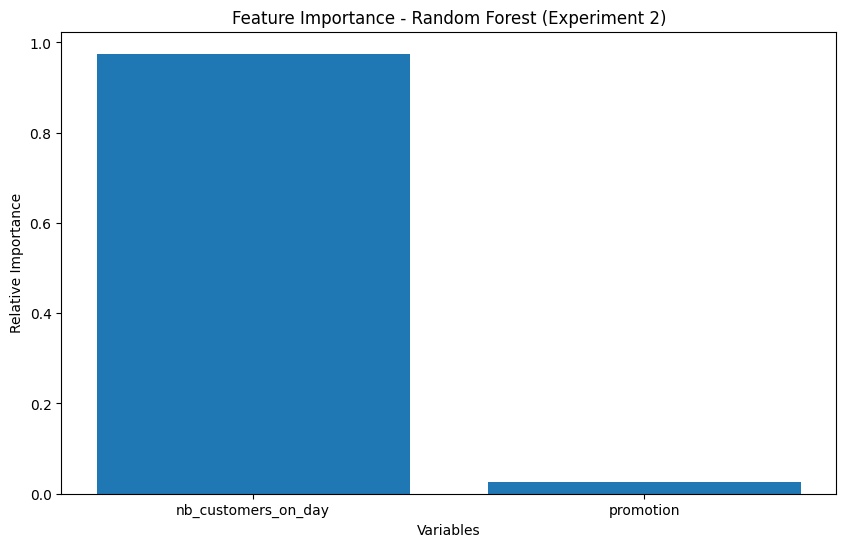

In [65]:
# Importancia de features para el Experimento 2
importances = rf_2.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance - Random Forest (Experiment 2)")
plt.bar(range(X_2.shape[1]), importances[indices], align="center")
plt.xticks(range(X_2.shape[1]), [X_2.columns[i] for i in indices])
plt.xlabel("Variables")
plt.ylabel("Relative Importance")
plt.show()

In [68]:
from sklearn.linear_model import LinearRegression

# Train Linear Regression on selected features
model_2 = LinearRegression()
model_2.fit(X_train_2, y_train_2)

y_pred_test_2 = model_2.predict(X_test_2)
rmse_test_2 = np.sqrt(mean_squared_error(y_test_2, y_pred_test_2))
r2_test_2 = r2_score(y_test_2, y_pred_test_2)

print(f"Linear Regression (Selected Features) - RMSE: {rmse_test_2:.2f}, R2: {r2_test_2:.4f}")

Linear Regression (Selected Features) - RMSE: 1626.00, R2: 0.7266


## 🧪 6. Specialized Modeling (Selected Features)
In this section, we train models using only a subset of features (`nb_customers_on_day` and `promotion`) to observe their individual impact on sales prediction.

In [69]:
# Select specific feature subset
X_2 = df_filtered[["nb_customers_on_day", "promotion"]]
y_2 = df_filtered["sales"]

# Split data for the second experiment
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

print(f"Experiment 2 - X_train shape: {X_train_2.shape}")

Experiment 2 - X_train shape: (425612, 2)


In [70]:
# Train Random Forest on selected features
rf_2 = RandomForestRegressor(n_estimators=100, max_depth=3, random_state=42, n_jobs=-1)
rf_2.fit(X_train_2, y_train_2)

y_pred_rf_2 = rf_2.predict(X_test_2)

rmse_rf_2 = np.sqrt(mean_squared_error(y_test_2, y_pred_rf_2))
r2_rf_2 = r2_score(y_test_2, y_pred_rf_2)

print(f"Random Forest (Selected Features) - RMSE: {rmse_rf_2:.2f}, R2: {r2_rf_2:.4f}")

Random Forest (Selected Features) - RMSE: 1719.34, R2: 0.6943


In [ ]:
# Feature importance for Experiment 2
importances = rf_2.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance - Random Forest (Experiment 2)")
plt.bar(range(X_2.shape[1]), importances[indices], align="center")
plt.xticks(range(X_2.shape[1]), [X_2.columns[i] for i in indices])
plt.xlabel("Variables")
plt.ylabel("Relative Importance")
plt.show()

In [71]:
# Train Linear Regression on selected features
model_2 = LinearRegression()
model_2.fit(X_train_2, y_train_2)

y_pred_test_2 = model_2.predict(X_test_2)
rmse_test_2 = np.sqrt(mean_squared_error(y_test_2, y_pred_test_2))
r2_test_2 = r2_score(y_test_2, y_pred_test_2)

print(f"Linear Regression (Selected Features) - RMSE: {rmse_test_2:.2f}, R2: {r2_test_2:.4f}")

Linear Regression (Selected Features) - RMSE: 1626.00, R2: 0.7266


## 📝 7. Conclusions & Insights
- Summarize key findings from EDA.
- Discuss model accuracy and potential improvements (e.g., trying non-linear models like Random Forest).
- Actionable insights for the business.